# Modélisation prédictive — Risque d'attrition des employés

Ce notebook a pour objectif de construire un modèle simple permettant d'estimer le risque de départ d'un employé.

La variable à prédire est `Attrition_Flag` :

- `1` = employé parti ;
- `0` = employé resté.

Le modèle ne remplace pas une décision RH. Il sert à identifier des signaux de risque et à aider à prioriser les actions de prévention.

In [27]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

In [4]:
data_path = Path("../data/processed/employee_attrition_clean.csv")
df = pd.read_csv(data_path)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0


In [5]:
df.shape

(1470, 32)

In [6]:
target = "Attrition_Flag"
y = df[target]
y.value_counts()

Attrition_Flag
0    1233
1     237
Name: count, dtype: int64

In [7]:
columns_to_exclude = ["Attrition", "Attrition_Flag"]
x = df.drop(columns=columns_to_exclude)
x.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,...,3,1,0,8,0,1,6,4,0,5
1,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,...,4,4,1,10,3,3,10,7,1,7
2,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,...,3,2,0,7,3,3,0,0,0,0
3,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,...,3,3,0,8,3,3,8,7,3,0
4,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,...,3,4,1,6,3,3,2,2,2,2


In [8]:
numeric_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = x.select_dtypes(include=["object"]).columns.tolist()

print("Variables numériques :")
print(numeric_features)

print("\nVariable catégorielles :")
print(categorical_features)

Variables numériques :
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Variable catégorielles :
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\nicoc\AppData\Local\Temp\ipykernel_37316\811455197.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x.select_dtypes(include=["object"]).columns.tolist()


In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Taille x_train : {x_train.shape}")
print(f"Taille x_test : {x_test.shape}")
print(f"Taille y_train : {y_train.shape}")
print(f"Taille y_test : {y_test.shape}")

Taille x_train : (1176, 30)
Taille x_test : (294, 30)
Taille y_train : (1176,)
Taille y_test : (294,)


In [10]:
preprocessor = ColumnTransformer (
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [11]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]
)

logistic_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [12]:
y_pred_logistic = logistic_model.predict(x_test)
y_proba_logistic = logistic_model.predict_proba(x_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_logistic), 3))
print("Precision :",  round(precision_score(y_test, y_pred_logistic), 3))
print("Recall :", round(recall_score(y_test, y_pred_logistic), 3))
print("F1-score :", round(f1_score(y_test, y_pred_logistic), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_logistic), 3))

print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_logistic))

Accuracy : 0.752
Precision : 0.349
Recall : 0.638
F1-score : 0.451
ROC-AUC : 0.803

Rapport détaillé :
              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294



In [13]:
conf_matrix_logistic = confusion_matrix(y_test, y_pred_logistic)

conf_matrix_logistic

array([[191,  56],
       [ 17,  30]])

In [14]:
random_forest_model = Pipeline(
    steps=[
       ("preprocessor", preprocessor),
       ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            max_depth=6
       )) 
    ]
)

random_forest_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [15]:
y_pred_rf = random_forest_model.predict(x_test)
y_proba_rf = random_forest_model.predict_proba(x_test)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision :", round(precision_score(y_test, y_pred_rf), 3))
print("Recall :", round(recall_score(y_test, y_pred_rf), 3))
print("F1-score :", round(f1_score(y_test, y_pred_rf), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_rf), 3))

print("\nRapport détaillé :")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.847
Precision : 0.525
Recall : 0.447
F1-score : 0.483
ROC-AUC : 0.791

Rapport détaillé :
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       247
           1       0.53      0.45      0.48        47

    accuracy                           0.85       294
   macro avg       0.71      0.68      0.70       294
weighted avg       0.84      0.85      0.84       294



In [16]:
models_comparison = pd.DataFrame([
    {
        "Modèle": "Régression logistique",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1-score": f1_score(y_test, y_pred_logistic),
        "ROC-AUC": roc_auc_score(y_test, y_proba_logistic)
    },
    {
       "Modèle": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_proba_rf) 
    }
])

models_comparison.round(3)

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Régression logistique,0.752,0.349,0.638,0.451,0.803
1,Random Forest,0.847,0.525,0.447,0.483,0.791


In [17]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / "attrition_random_forest_model.pkl"

joblib.dump(random_forest_model, model_path)

print(f"Modèle sauvegardé ici : {model_path}")

Modèle sauvegardé ici : ..\models\attrition_random_forest_model.pkl


In [18]:
features_path = models_dir / "model_features.pkl"

joblib.dump(x.columns.tolist(), features_path)

print(f"Liste des variables sauvegardée ici : {features_path}")

Liste des variables sauvegardée ici : ..\models\model_features.pkl


## Conclusion

Deux modèles ont été testés pour prédire le risque d'attrition :

- une régression logistique, simple et facilement interprétable ;
- un modèle Random Forest, plus flexible et capable de capturer des relations plus complexes.

L'objectif principal n'est pas d'obtenir un modèle parfait, mais de créer un outil d'aide à l'analyse RH.

Dans un contexte réel, ce type de modèle devrait être utilisé avec prudence, car il ne prouve pas pourquoi un employé part. Il permet plutôt d'identifier des profils à surveiller et d'appuyer les décisions RH avec des données.

## 6. Interprétation des variables importantes

In [19]:
preprocessor_fitted = random_forest_model.named_steps["preprocessor"]
numeric_feature_names = numeric_features
categorical_feature_names = preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
all_feature_names = list(numeric_feature_names) + list(categorical_feature_names)
all_feature_names[:10]

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome']

In [20]:
rf_model = random_forest_model.named_steps["model"]
rf_importances = rf_model.feature_importances_
rf_feature_importance = pd.DataFrame({
    "Variable": all_feature_names,
    "Importance": rf_importances
})
rf_feature_importance = rf_feature_importance.sort_values("Importance", ascending=False)
rf_feature_importance.head(15)

,Variable,Importance
9,MonthlyIncome,0.081652
16,TotalWorkingYears,0.070875
0,Age,0.065409
19,YearsAtCompany,0.056842
49,OverTime_No,0.049409
50,OverTime_Yes,0.046054
22,YearsWithCurrManager,0.044098
1,DailyRate,0.041031
15,StockOptionLevel,0.040251
7,JobLevel,0.034915


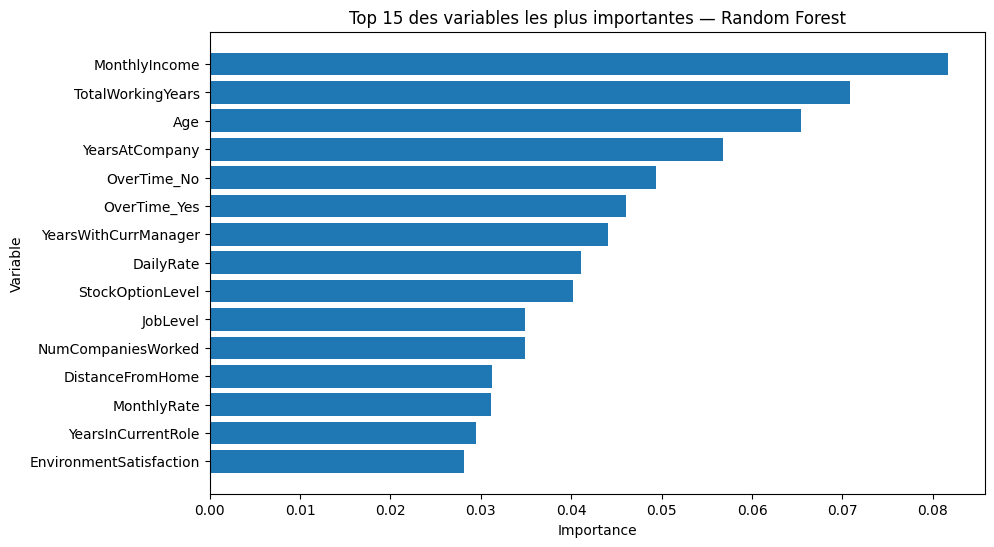

In [28]:
top_rf_features = rf_feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_rf_features["Variable"], top_rf_features["Importance"])
plt.title("Top 15 des variables les plus importantes — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()

In [22]:
logistic_preprocessor_fitted = logistic_model.named_steps["preprocessor"]
logistic_categorical_feature_names = logistic_preprocessor_fitted.named_transformers_["cat"].get_feature_names_out(categorical_features)
logistic_all_feature_names = list(numeric_features) + list(logistic_categorical_feature_names)
logistic_coefficients = logistic_model.named_steps["model"].coef_[0]
logistic_feature_importance = pd.DataFrame({
    "Variable": logistic_all_feature_names,
    "Coefficient": logistic_coefficients
})
logistic_feature_importance["Importance_absolue"] = logistic_feature_importance["Coefficient"].abs()
logistic_feature_importance = logistic_feature_importance.sort_values("Importance_absolue", ascending=False)
logistic_feature_importance.head(15)

,Variable,Coefficient,Importance_absolue
42,JobRole_Research Director,-1.465683,1.465683
39,JobRole_Laboratory Technician,1.194333,1.194333
45,JobRole_Sales Representative,1.120617,1.120617
23,BusinessTravel_Non-Travel,-0.993885,0.993885
49,OverTime_No,-0.892809,0.892809
33,EducationField_Other,-0.798108,0.798108
24,BusinessTravel_Travel_Frequently,0.787566,0.787566
50,OverTime_Yes,0.761522,0.761522
29,EducationField_Human Resources,0.721129,0.721129
37,JobRole_Healthcare Representative,-0.647202,0.647202


In [23]:
risk_increasing_factors = logistic_feature_importance[
    logistic_feature_importance["Coefficient"] > 0
].sort_values("Coefficient", ascending=False)

risk_decreasing_factors = logistic_feature_importance[
    logistic_feature_importance["Coefficient"] < 0
].sort_values("Coefficient", ascending=True)

print("Facteurs qui augmentent le risque de départ :")
display(risk_increasing_factors.head(10))

print("Facteurs qui diminuent le risque de départ :")
display(risk_decreasing_factors.head(10))

Facteurs qui augmentent le risque de départ :


,Variable,Coefficient,Importance_absolue
39,JobRole_Laboratory Technician,1.194333,1.194333
45,JobRole_Sales Representative,1.120617,1.120617
24,BusinessTravel_Travel_Frequently,0.787566,0.787566
50,OverTime_Yes,0.761522,0.761522
29,EducationField_Human Resources,0.721129,0.721129
7,JobLevel,0.607426,0.607426
21,YearsSinceLastPromotion,0.502531,0.502531
38,JobRole_Human Resources,0.463886,0.463886
11,NumCompaniesWorked,0.460496,0.460496
48,MaritalStatus_Single,0.457277,0.457277


Facteurs qui diminuent le risque de départ :


,Variable,Coefficient,Importance_absolue
42,JobRole_Research Director,-1.465683,1.465683
23,BusinessTravel_Non-Travel,-0.993885,0.993885
49,OverTime_No,-0.892809,0.892809
33,EducationField_Other,-0.798108,0.798108
37,JobRole_Healthcare Representative,-0.647202,0.647202
16,TotalWorkingYears,-0.620234,0.620234
46,MaritalStatus_Divorced,-0.482231,0.482231
22,YearsWithCurrManager,-0.454674,0.454674
4,EnvironmentSatisfaction,-0.426185,0.426185
8,JobSatisfaction,-0.388876,0.388876


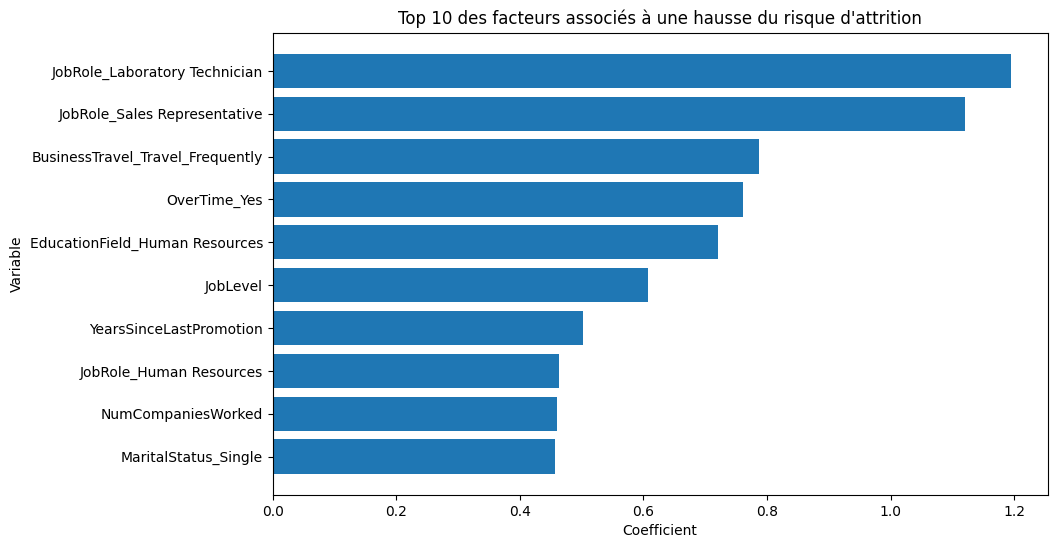

In [29]:
top_risk_increasing = risk_increasing_factors.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_risk_increasing["Variable"], top_risk_increasing["Coefficient"])
plt.title("Top 10 des facteurs associés à une hausse du risque d'attrition")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()

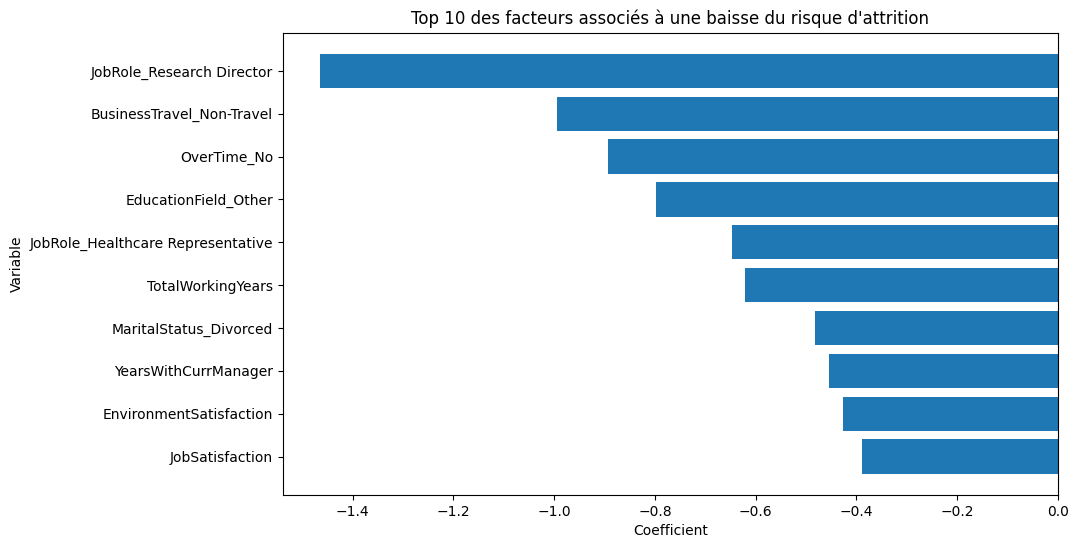

In [30]:
top_risk_decreasing = risk_decreasing_factors.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_risk_decreasing["Variable"], top_risk_decreasing["Coefficient"])
plt.title("Top 10 des facteurs associés à une baisse du risque d'attrition")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.gca().invert_yaxis()
plt.show()

In [24]:
output_dir = Path("../data/processed")

rf_feature_importance.to_csv(output_dir / "feature_importance_random_forest.csv", index=False)
logistic_feature_importance.to_csv(output_dir / "feature_importance_logistic_regression.csv", index=False)

print("Résultats d'importance des variables sauvegardés avec succès.")

Résultats d'importance des variables sauvegardés avec succès.


In [25]:
logistic_model_path = models_dir / "attrition_logistic_model.pkl"

joblib.dump(logistic_model, logistic_model_path)

print(f"Modèle de régression logistique sauvegardé ici : {logistic_model_path}")

Modèle de régression logistique sauvegardé ici : ..\models\attrition_logistic_model.pkl


In [26]:
final_model_path = models_dir / "attrition_final_model.pkl"

joblib.dump(logistic_model, final_model_path)

print(f"Modèle final sauvegardé ici : {final_model_path}")

Modèle final sauvegardé ici : ..\models\attrition_final_model.pkl


## Conclusion sur l'interprétation du modèle

L'analyse des variables importantes permet de mieux comprendre les principaux facteurs associés au risque d'attrition.

Le modèle Random Forest met en évidence les variables les plus utilisées pour effectuer les prédictions, tandis que la régression logistique permet d'interpréter le sens de l'effet : certaines variables augmentent le risque estimé de départ, tandis que d'autres semblent associées à une probabilité plus faible de départ.

Cette étape est essentielle pour transformer un modèle prédictif en outil d'aide à la décision RH. L'objectif n'est pas seulement de prédire un départ potentiel, mais aussi d'identifier les leviers sur lesquels l'entreprise peut agir : charge de travail, satisfaction, équilibre vie professionnelle / personnelle, intégration des nouveaux employés ou évolution de carrière.